In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt


In [3]:
aliens = pd.read_csv("../data/ben10_aliens.csv")
aliens.head()


,alien_id,alien_name,species,home_planet,strength_level,speed_level,intelligence
0,1,Alien X,Indeedite,Andromeda Prime,7,8,6
1,2,AmpFibian,Particularite,Zantron,5,8,5
2,3,Armodrillo,Discussionite,Tierra Nova,5,4,10
3,4,Astrodactyl,Acrossite,Hala,10,7,8
4,5,Atomix,Eastite,Sirius,10,5,10


In [4]:
X = aliens[["strength_level", "speed_level", "intelligence"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


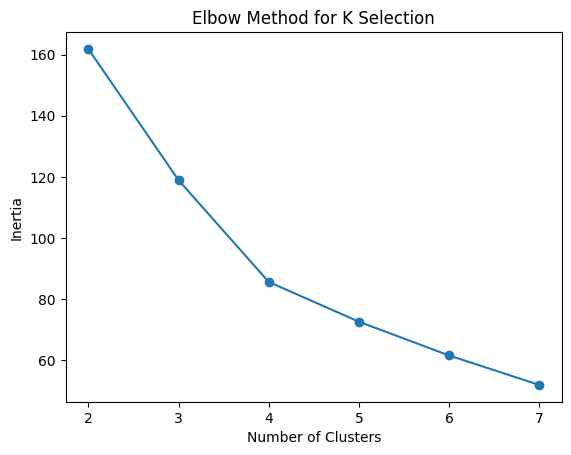

In [6]:
plt.figure()
plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K Selection")
plt.show()


In [7]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")


k=2, silhouette=0.256
k=3, silhouette=0.290
k=4, silhouette=0.336
k=5, silhouette=0.314
k=6, silhouette=0.302
k=7, silhouette=0.306


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
aliens["cluster"] = kmeans.fit_predict(X_scaled)


In [9]:
cluster_profiles = aliens.groupby("cluster")[[
    "strength_level", "speed_level", "intelligence"
]].mean()

cluster_profiles


,strength_level,speed_level,intelligence
cluster,,,
0,6.315789,6.894737,9.473684
1,9.105263,9.105263,7.631579
2,8.750000,4.708333,7.166667
3,5.666667,7.083333,5.750000


In [10]:
cluster_names = {
    0: "Brute Force",
    1: "Speedster",
    2: "Strategist",
    3: "Balanced"
}

aliens["archetype"] = aliens["cluster"].map(cluster_names)


In [11]:
aliens[["alien_name", "archetype"]].sort_values("archetype")


,alien_name,archetype
0,Alien X,Balanced
43,Pesky Dust,Balanced
29,Gravattack,Balanced
46,Shock Rock,Balanced
49,Snare-oh,Balanced
...,...,...
30,Grey Matter,Strategist
32,Heatblast,Strategist
72,Wildvine,Strategist
17,Ditto,Strategist


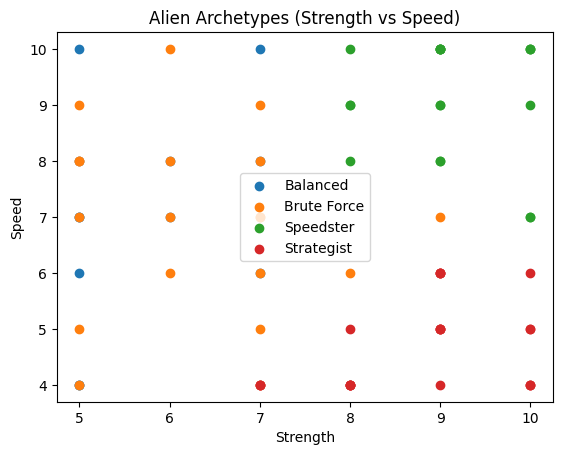

In [12]:
plt.figure()
for archetype in aliens["archetype"].unique():
    subset = aliens[aliens["archetype"] == archetype]
    plt.scatter(
        subset["strength_level"],
        subset["speed_level"],
        label=archetype
    )

plt.xlabel("Strength")
plt.ylabel("Speed")
plt.title("Alien Archetypes (Strength vs Speed)")
plt.legend()
plt.show()


In [14]:
aliens.to_csv("../data/processed/aliens_with_archetypes.csv", index=False)
